# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [2]:
from sklearn.model_selection import train_test_split

X = df[df.columns.drop(["salary_in_usd", "salary"])] #признаки
y = df["salary_in_usd"] #целевая переменная

X_train, X_val_and_test, y_train, y_val_and_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_val_and_test, y_val_and_test, test_size=0.5, random_state=0)

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

train_ohe_values = enc.fit_transform(X_train[categorical_features])
train_ohe_df = pd.DataFrame(train_ohe_values, index=X_train.index, columns=enc.get_feature_names_out())
X_train_ohe = pd.concat([X_train.drop(columns=categorical_features), train_ohe_df], axis=1)

test_ohe_values = enc.transform(X_test[categorical_features])
test_ohe_df = pd.DataFrame(test_ohe_values, index=X_test.index, columns=enc.get_feature_names_out())
X_test_ohe = pd.concat([X_test.drop(columns=categorical_features), test_ohe_df], axis=1)

lr = LinearRegression()
lr.fit(X_train_ohe, y_train)

print('MAPE: ', mean_absolute_percentage_error(y_test, lr.predict(X_test_ohe)))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, lr.predict(X_test_ohe))))

MAPE:  0.37152155122254193
RMSE:  54610.08939218799


C:\Anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [4]:
val_ohe_values = enc.transform(X_val[categorical_features])
val_ohe_df = pd.DataFrame(val_ohe_values, index=X_val.index, columns=enc.get_feature_names_out())
X_val_ohe = pd.concat([X_val.drop(columns=categorical_features), val_ohe_df], axis=1)

C:\Anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [23]:
from xgboost.sklearn import XGBRegressor
import itertools

param_grid = {
    'max_depth' : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3] ,
    'n_estimators' : [5, 10, 15, 20],
    'gamma' : np.linspace(0, 1, 10),
    'subsample':  [0.6, 0.7, 0.8, 0.9, 1.], 
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.]
}

results = []

for combo in itertools.product(*param_grid.values()): #перебор комбинаций
    params = dict(zip(param_grid.keys(), combo)) #название: значение
    model_xgb = XGBRegressor(objective="reg:squarederror", random_state=0, **params)
    model_xgb.fit(X_train_ohe, y_train)

    y_pred = model_xgb.predict(X_val_ohe)
    mse = mean_squared_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)

    results.append({**params, 'mse': mse, 'mape': mape})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mse'].idxmin()]
print(best_row)

max_depth           5.000000e+00
learning_rate       3.000000e-01
n_estimators        1.000000e+01
gamma               0.000000e+00
subsample           6.000000e-01
colsample_bytree    1.000000e+00
mse                 2.433319e+09
mape                3.654670e-01
Name: 7254, dtype: float64


In [24]:
import time

best_params = {
    'max_depth' : int(best_row['max_depth']),
    'learning_rate' : best_row['learning_rate'] ,
    'n_estimators' : int(best_row['n_estimators']),
    'gamma' : best_row['gamma'],
    'subsample': best_row['subsample'], 
    'colsample_bytree': best_row['colsample_bytree'],
    'objective': 'reg:squarederror',
    'random_state': 0
}

start_train = time.time() #текущее время
best_model = XGBRegressor(**best_params)
best_model.fit(X_train_ohe, y_train)
train_time = time.time() - start_train #время обучения

start_pred = time.time()
pred_test = best_model.predict(X_test_ohe)
pred_time = time.time() - start_pred

mape_test = mean_absolute_percentage_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

In [25]:
print('MAPE: ', mape_test )
print('RMSE: ', rmse_test )
print('Время обучения: ', train_time)
print('Время предсказания: ', pred_time)

MAPE:  0.3685685396194458
RMSE:  52432.07567892005
Время обучения:  0.08697748184204102
Время предсказания:  0.022938251495361328


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [29]:
from catboost import CatBoostRegressor

param_grid = {
    'depth' : [4, 6, 8],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'iterations' : [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5],
    'subsample':  [0.6, 0.7, 0.8, 0.9, 1.]
}
    
results = []

for combo in itertools.product(*param_grid.values()): #перебор комбинаций
    params = dict(zip(param_grid.keys(), combo)) #название: значение
    model_cbr = CatBoostRegressor(**params, verbose=False, random_state=0)
    model_cbr.fit(X_train_ohe, y_train)

    y_pred = model_cbr.predict(X_val_ohe)
    mse = mean_squared_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)

    results.append({**params, 'mse': mse, 'mape': mape})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mse'].idxmin()]
print(best_row)

depth            6.000000e+00
learning_rate    3.000000e-01
iterations       1.000000e+02
l2_leaf_reg      5.000000e+00
subsample        7.000000e-01
mse              2.397391e+09
mape             3.450212e-01
Name: 326, dtype: float64


In [30]:
best_params = {
    'depth' : int(best_row['depth']),
    'learning_rate' : best_row['learning_rate'] ,
    'iterations' : int(best_row['iterations']),
    'l2_leaf_reg' : best_row['l2_leaf_reg'],
    'subsample': best_row['subsample'],
    'verbose': 0,
    'random_state': 0
}

start_train = time.time() #текущее время
best_model = CatBoostRegressor(**best_params)
best_model.fit(X_train_ohe, y_train)
train_time = time.time() - start_train #время обучения

start_pred = time.time()
pred_test = best_model.predict(X_test_ohe)
pred_time = time.time() - start_pred

mape_test = mean_absolute_percentage_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print('MAPE: ', mape_test )
print('RMSE: ', rmse_test )
print('Время обучения: ', train_time)
print('Время предсказания: ', pred_time)

MAPE:  0.3528750895897458
RMSE:  51814.68156229418
Время обучения:  0.3721606731414795
Время предсказания:  0.014958858489990234


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [31]:
from catboost import Pool

cat_features = X_train.select_dtypes(include=['object']).columns.tolist() #список признаков

train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
val_pool = Pool(data=X_val, label=y_val, cat_features=cat_features)

param_grid = {
    'depth' : [4, 6, 8],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'iterations' : [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5],
    'subsample':  [0.6, 0.7, 0.8, 0.9, 1.]
}

results = []

for combo in itertools.product(*param_grid.values()): #перебор комбинаций
    params = dict(zip(param_grid.keys(), combo)) #название: значение
    model_cbr = CatBoostRegressor(**params, verbose=False, random_state=0)
    model_cbr.fit(train_pool)

    y_pred = model_cbr.predict(val_pool)
    mse = mean_squared_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)

    results.append({**params, 'mse': mse, 'mape': mape})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mse'].idxmin()]
print(best_row)

depth            6.000000e+00
learning_rate    3.000000e-01
iterations       1.000000e+02
l2_leaf_reg      3.000000e+00
subsample        1.000000e+00
mse              2.332415e+09
mape             3.217260e-01
Name: 324, dtype: float64


In [32]:
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

best_params = {
    'depth' : int(best_row['depth']),
    'learning_rate' : best_row['learning_rate'] ,
    'iterations' : int(best_row['iterations']),
    'l2_leaf_reg' : best_row['l2_leaf_reg'],
    'subsample': best_row['subsample'],
    'verbose': 0,
    'random_state': 0
}

start_train = time.time() #текущее время
best_model = CatBoostRegressor(**best_params)
best_model.fit(train_pool)
train_time = time.time() - start_train #время обучения

start_pred = time.time()
pred_test = best_model.predict(test_pool)
pred_time = time.time() - start_pred

mape_test = mean_absolute_percentage_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print('MAPE: ', mape_test )
print('RMSE: ', rmse_test )
print('Время обучения: ', train_time)
print('Время предсказания: ', pred_time)

MAPE:  0.3508222450267793
RMSE:  51141.182408785
Время обучения:  2.371638059616089
Время предсказания:  0.0014157295227050781


**Ответ:** Да, при использовании Pool качество улучшилось: MAPE снизилось с 0.3529 до 0.3508, а RMSE с 51814 до 51141. Время обучения увеличилось с 0.372 до 2.372, а время предсказания уменьшилось с 0.015 до 0.001.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [8]:
from lightgbm import LGBMRegressor
import itertools

param_grid = {
    'max_depth' : [5, 7, 9, 11, 13, 15],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'n_estimators' : [100, 200, 300],
    'bagging_fraction' : [0.5, 0.7, 0.9]
}

results = []

for combo in itertools.product(*param_grid.values()): #перебор комбинаций
    params = dict(zip(param_grid.keys(), combo)) #название: значение
    model_lgbm = LGBMRegressor(objective="regression", metric="mse", random_state=0, **params)
    model_lgbm.fit(X_train_ohe, y_train)

    y_pred = model_lgbm.predict(X_val_ohe)
    mse = mean_squared_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)

    results.append({**params, 'mse': mse, 'mape': mape})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mse'].idxmin()]
print(best_row)

[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 39
[LightGBM] [Info] Start training from score 136404.995340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [11]:
import time

best_params = {
    'max_depth' : int(best_row['max_depth']),
    'learning_rate' : best_row['learning_rate'] ,
    'n_estimators' : int(best_row['n_estimators']),
    'bagging_fraction' : best_row['bagging_fraction'],
    'objective': 'regression',
    'metric': 'mse',
    'random_state': 0
}

start_train = time.time() #текущее время
best_model = LGBMRegressor(**best_params)
best_model.fit(X_train_ohe, y_train)
train_time = time.time() - start_train #время обучения

start_pred = time.time()
pred_test = best_model.predict(X_test_ohe)
pred_time = time.time() - start_pred

mape_test = mean_absolute_percentage_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print('MAPE: ', mape_test )
print('RMSE: ', rmse_test )
print('Время обучения: ', train_time)
print('Время предсказания: ', pred_time)

[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 39
[LightGBM] [Info] Start training from score 136404.995340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** 

Лучше всего по точности сработал LightGBM (наименьшая MAPE), он лучше всех предсказал относительные значения. CatBoost с использованием Pool дал минимальную абсолютную ошибку (наименьший RMSE), то есть точнее угадал конкретные зарплаты. Линейная модель показала худший результат — ей сложно справляться со сложными зависимостями.

По скорости обучения быстрее всех оказался XGBoost — он быстро обучается за счёт оптимизаций. Дольше всех обучался CatBoost через Pool, так как он дополнительно обрабатывает категориальные признаки внутри себя.

По скорости предсказания лидировал CatBoost с Pool — у него быстрый алгоритм на этапе прогнозов. XGBoost предсказывает медленнее всех.

У разных моделей разные важные гиперпараметры: XGBoost сильно зависит от параметров регуляризации (gamma, subsample, colsample_bytree), LightGBM — от внутреннего бэггинга (bagging_fraction), а CatBoost сам по себе проще — основные параметры: глубина дерева, скорость обучения, количество итераций.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [5]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [6]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [7]:
ratings= ratings.drop(['user'], axis=0)
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [8]:
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
rihanna & jay-z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [14]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=5)
k_means = k_means.fit(ratings)
clusters = k_means.predict(ratings)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [15]:
unique_clusters, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique_clusters, counts):
    print(f"Кластер {cluster + 1}: {count} исполнителей")

Кластер 1: 1 исполнителей
Кластер 2: 1 исполнителей
Кластер 3: 996 исполнителей
Кластер 4: 1 исполнителей
Кластер 5: 1 исполнителей


**Ответ:** 

Кластеризация получилась бесполезной, т.к. кластеры оказались сильно несбалансированными (996 исполнителей попали в 3-ий кластер). Скорее всего, K-means объединил исполнителей с большим количеством нулей при расчете расстояний, посчитав их похожими.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [16]:
clusters_with_size1 = unique_clusters[counts == 1] 

indexes = [i for i, cluster in enumerate(clusters) if cluster in clusters_with_size1] 

singers = [ratings.index[i] for i in indexes] 

print(*singers, sep=', ')

the beatles, kanye west, fiona apple, judas priest


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [17]:
listeners_count = (ratings > 0).sum(axis=1)
listeners_percent = listeners_count / ratings.shape[1]
mean_listen_percent = ratings.mean(axis=1)

print(f'Доля пользователей, слушающих The Beatles {listeners_percent["the beatles"]}')
print(f'Средняя доля прослушивания The Beatles: {mean_listen_percent["the beatles"]}')

Доля пользователей, слушающих The Beatles 0.3342
Средняя доля прослушивания The Beatles: 0.01836897659205146


In [18]:
listeners_percent.sort_values(ascending=False).head(10)

the beatles              0.3342
radiohead                0.2778
deathcab for cutie       0.1862
coldplay                 0.1682
modest mouse             0.1628
sufjan stevens           0.1292
dylan. bob               0.1262
red hot clili peppers    0.1258
pink fluid               0.1256
kanye west               0.1250
dtype: float64

In [19]:
mean_listen_percent.sort_values(ascending=False).head(10)

the beatles           0.018369
radiohead             0.011851
deathcab for cutie    0.006543
niИ                   0.006470
coldplay              0.006030
modest mouse          0.005876
sufjan stevens        0.004969
dylan. bob            0.004963
pink fluid            0.004909
elliotte smith        0.004842
dtype: float64

**Ответ:**

The Beatles могут выделяться из-за того, что они имеют самую высокую долю прослушиваний среди всех исполнителей. Похожих по этому признаку объектов почти нет, поэтому K-Means выделяет The Beatles в отдельный кластер.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [20]:
from sklearn.preprocessing import normalize

ratings_normalized = normalize(ratings, axis=1)
ratings_normalized = pd.DataFrame(ratings_normalized, index=ratings.index, columns=ratings.columns)
ratings_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [21]:
k_means = KMeans(n_clusters=5)
k_means = k_means.fit(ratings_normalized)
clusters = k_means.predict(ratings_normalized)

In [22]:
unique_clusters, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique_clusters, counts):
    print(f"Кластер {cluster}: {count} исполнителей")

Кластер 0: 96 исполнителей
Кластер 1: 102 исполнителей
Кластер 2: 105 исполнителей
Кластер 3: 273 исполнителей
Кластер 4: 424 исполнителей


**Ответ** 

Да, стало намного лучше и теперь кластеризация может быть полезна, т.к. размеры кластеров стали более равномерными.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [23]:
from scipy.spatial.distance import cosine

centroids = k_means.cluster_centers_

for cluster_num in range(5):
    cluster_indexes = np.where(clusters == cluster_num)[0] #индексы исполнителей
    distances = [cosine(ratings_normalized.iloc[i], centroids[cluster_num]) for i in cluster_indexes]
    top_indexes = cluster_indexes[np.argsort(distances)[0:10]]
    print(f"\nКластер {cluster_num + 1}:")
    print(*ratings_normalized.index[top_indexes].tolist(), sep=", ")


Кластер 1:
metallica, iron maiden, koЯn, megadeth, slayer, niИ, tool, system of a down, pantera, marilyn manson

Кластер 2:
nas, jay-z, kanye west, lupe the gorilla, a tribe called quest, the roots featuring d'angelo, mos def, little brother, lil' wayne, talib kweli

Кластер 3:
blink-182, brand new, alkaline trio, against me!, less than jake, underoath, chiodos, new found glory, thrice, saosin

Кластер 4:
the beatles, the rolling stones, velvet underground, dylan. bob, sonic youth, the pixies, led zeppelin., divid bowie, young, neil, who

Кластер 5:
deathcab for cutie, radiohead, coldplay, the shins, sufjan stevens, the killers, the arcade fire, the postal service, ironand wine, bright eyes


**Ответ:**

Центроиды каждого кластера — это средние «образы» исполнителей с похожими профилями прослушиваний. Алгоритм выделил группы исполнителей, которые схожи по музыкальным предпочтениям пользователей, и эти группы, совпали с жанрами музыки.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

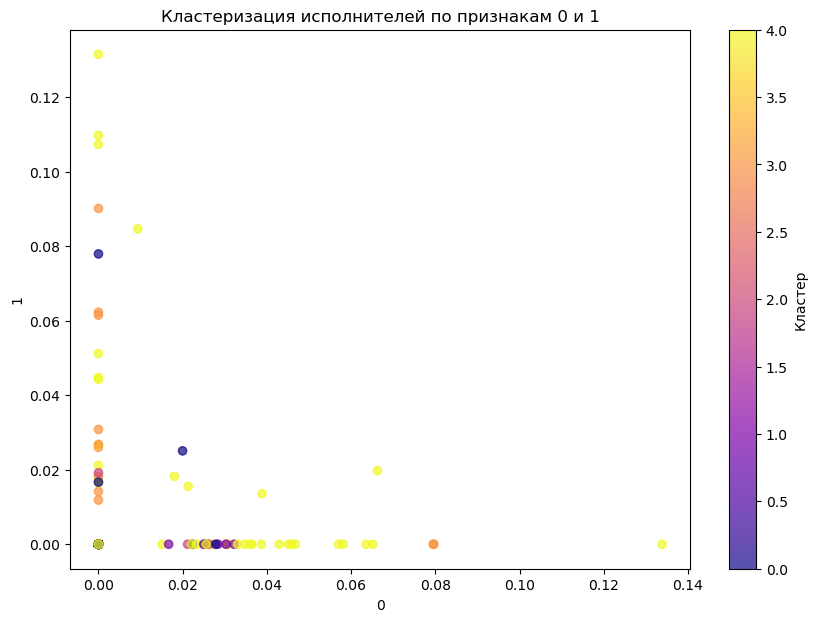

In [24]:
import matplotlib.pyplot as plt

feature_x = ratings_normalized.columns[0]
feature_y = ratings_normalized.columns[1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(ratings_normalized[feature_x], ratings_normalized[feature_y], c=clusters, cmap='plasma', alpha=0.7)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f'Кластеризация исполнителей по признакам {feature_x} и {feature_y}')
plt.colorbar(scatter, label='Кластер')
plt.show()

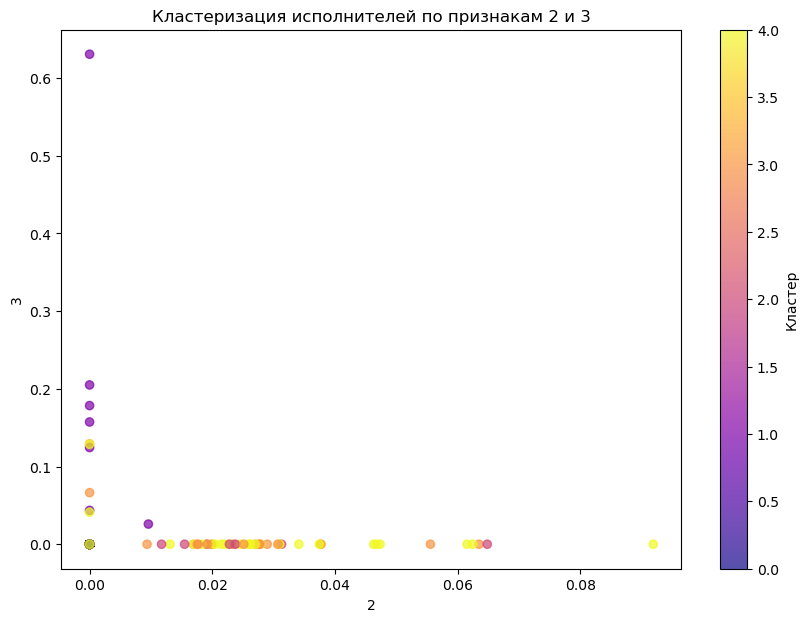

In [25]:
feature_x = ratings_normalized.columns[2]
feature_y = ratings_normalized.columns[3]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(ratings_normalized[feature_x], ratings_normalized[feature_y], c=clusters, cmap='plasma', alpha=0.7)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f'Кластеризация исполнителей по признакам {feature_x} и {feature_y}')
plt.colorbar(scatter, label='Кластер')
plt.show()

**Ответ:** 

Кластеры на графике выглядят размыто и плохо отражают разделение на кластеры, потому что мы показываем только 2 признака из многих. На самом деле кластеры хорошо разделяются в многомерном пространстве, а на плоскости это не видно. Чтобы лучше визуализировать распределение кластеров, лучше использовать методы снижения размерности, например PCA или t-SNE.

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

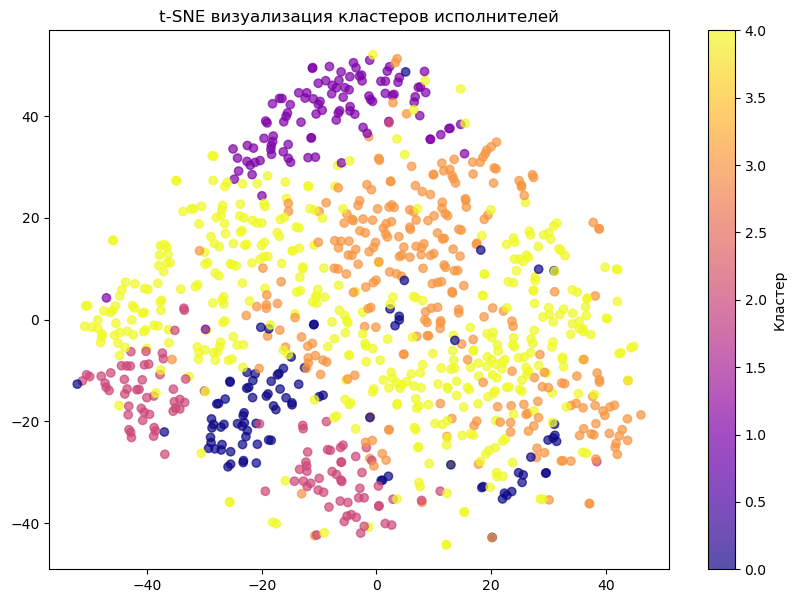

In [26]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0, perplexity=30)
ratings_tsne = tsne.fit_transform(ratings_normalized)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=clusters, cmap='plasma', alpha=0.7)
plt.title("t-SNE визуализация кластеров исполнителей")
plt.colorbar(scatter, label='Кластер')
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [27]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 101):
    k_means = KMeans(n_clusters = k, random_state=42)
    k_means = k_means.fit(ratings_normalized)
    clusters = k_means.predict(ratings_normalized)

    score = silhouette_score(ratings_normalized, clusters)

    scores.append((k, score))

best_k, best_score = max(scores, key=lambda x: x[1])

print(f"Оптимальное количество кластеров: {best_k}")
print(f"Максимальный silhouette score: {best_score}")

Оптимальное количество кластеров: 98
Максимальный silhouette score: 0.01332710844154191


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [33]:
k_means = KMeans(n_clusters = best_k, random_state=42)
k_means = k_means.fit(ratings_normalized)
clusters = k_means.predict(ratings_normalized)

centroids = k_means.cluster_centers_

top_singers = []

for cluster_num in range(best_k):
    cluster_indexes = np.where(clusters == cluster_num)[0] #индексы исполнителей
    distances = [cosine(ratings_normalized.iloc[i], centroids[cluster_num]) for i in cluster_indexes]
    top_indexes = cluster_indexes[np.argsort(distances)[0:10]]
    singers = ratings_normalized.index[top_indexes].tolist()
    top_singers.append({'cluster': cluster_num, 'singers': singers})

result_df = pd.DataFrame(top_singers)
result_df.head(20)

,cluster,singers
0,0,"[dr. dre, the faint, violent femmes, margot an..."
1,1,"[john mayer, matt nathanson, gavin degraw, jas..."
2,2,"[white stripes, beck, the raconteurs, spoon, t..."
3,3,"[fugazi, jawbreaker, sleater-kinney, les savy ..."
4,4,"[ryan adams, band of horses, ryan adams and th..."
5,5,"[dj shadow, rjd2, amon tobin, jedi mind tricks..."
6,6,"[system of a down, koЯn, mudvayne, limpt bizki..."
7,7,"[somethings corporate, the rocket summer, jack..."
8,8,"[chiodos, underoath, scary kids scaring kids, ..."
9,9,"[the police, peter gabriël, r.e.m., bush, sade]"


**Ответ:** 

Да, смысл кластеров остался прежним, кластеры все также выделяют похожих по жанру исполнителей. Так, например, кластер 15 объединил мужских исполнителей в стиле R&B и хип-хоп, а кластер 11 - исполнительниц в стиле соул.

Сделайте t-SNE визуализацию полученной кластеризации.

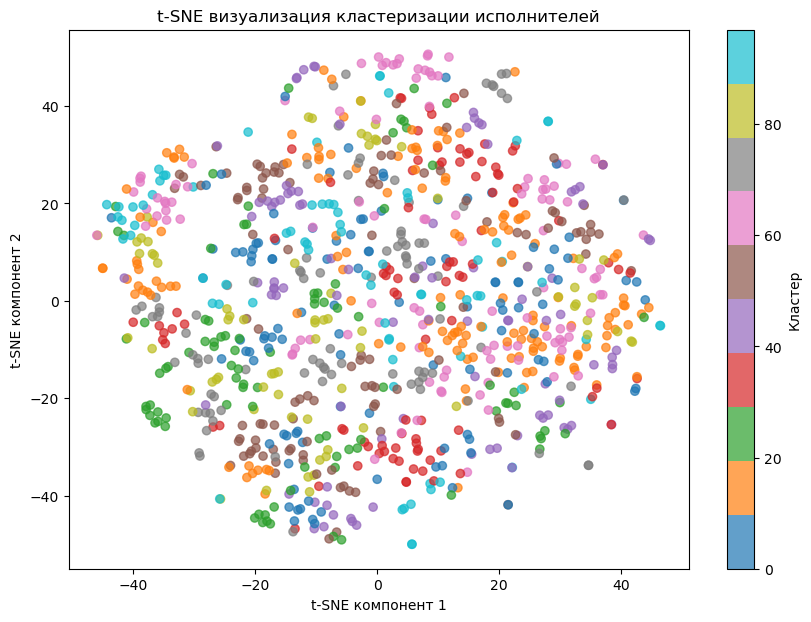

In [34]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
ratings_tsne = tsne.fit_transform(ratings_normalized)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=clusters, cmap='tab10', alpha=0.7)
plt.title('t-SNE визуализация кластеризации исполнителей')
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.colorbar(scatter, label='Кластер')
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

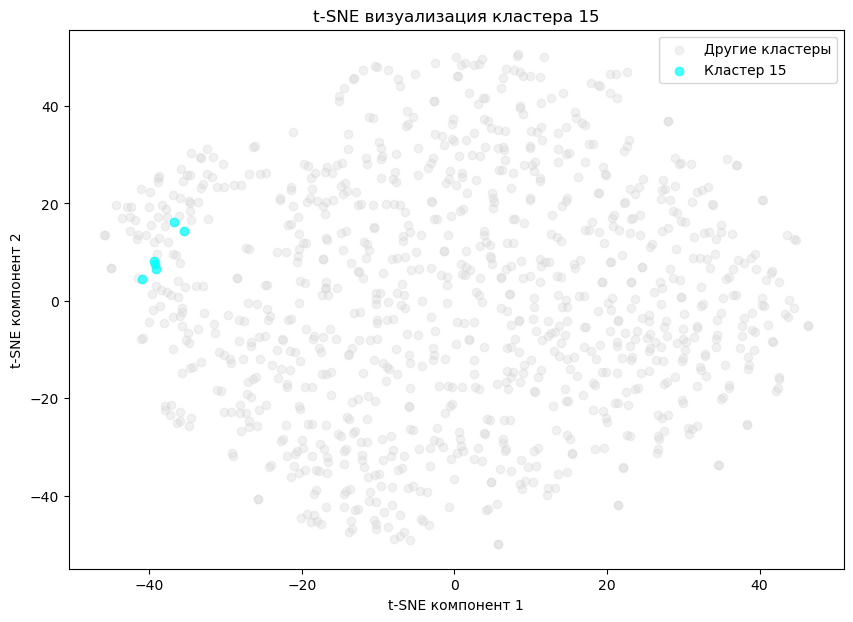

In [36]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
ratings_tsne = tsne.fit_transform(ratings_normalized)

interesting_cluster = 15

plt.figure(figsize=(10, 7))

plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c='lightgray', alpha=0.3, label='Другие кластеры')

mask = (clusters == interesting_cluster)
plt.scatter(ratings_tsne[mask, 0], ratings_tsne[mask, 1], c='cyan', alpha=0.7, label=f'Кластер {interesting_cluster}')

plt.title(f't-SNE визуализация кластера {interesting_cluster}')
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.legend()
plt.show()

**Ответ:** 

После выделения кластера 15 его стало достаточно хорошо видно на визуализации, а также исполнители, относящиеся к нему довольно близки в признаковом пространстве.